In [108]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import pickle
from pathlib import Path

#all_trials = pd.read_parquet(Path("notebook_outputs") / "all_trials_cached.parquet")

In [109]:
import pickle

with open("notebook_outputs/q1_workspace.pkl", "rb") as f:
    globals().update(pickle.load(f))

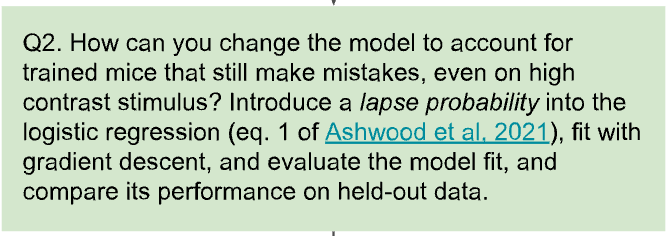

### Q2-1. From Q1 to Lapse Analysis

In Q1, logistic regression captured the main relationship between `signed_contrast` and mouse choice. As contrast increased, the probability of `choice_binary = 1` also increased.
In Q1, we used standard logistic regression to model how signed_contrast affects the mouse’s choice.

The model captured the main trend well with Logistic Regression:

$$
P(Y=1 \mid x)
=

\operatorname{sigmoid}(\beta_0+\beta_1x)
$$

The sigmoid function is:

$$
\operatorname{sigmoid}(z)
=

\frac{1}{1+e^{-z}}
$$



### Q2-2. However, some mice still made errors at high contrast. 
##### Standard logistic regression usually predicts probabilities close to 0 or 1 at high contrast, so it may not capture these lapse errors.
Ashwood et al. suggest that lapses may not be completely random. 
Mice can switch between engaged and disengaged behavioral states, and disengaged states can continue across several trials. 

High-contrast errors:

`abs(signed_contrast) >= 0.5` and `feedbackType == -1`


### Q2-3. The mouse sometimes chooses based on the stimulus, and sometimes makes a random choice because of a lapse.

So, we build a new, extended model:

- Logistic regression describes the mouse’s choice based on signed_contrast(Q1).

- λ describes how often the mouse ignores the stimulus and chooses randomly.

- sklearn.LogisticRegression cannot estimate λ, so for the lapse model we usually write our own probability function and optimize the negative log-likelihood.


Это формула логистической регрессией с учетом + lapse_probability


$$ P =
\frac{\lambda}{2}
+
(1 - \lambda)
\cdot
\frac{1}{1 + e^{-(b + wx)}}
$$


### Q2-4. How we get prev formula?


We use 0.5 because during a lapse, 

we assume that the mouse chooses randomly between two possible choices: 0 and 1. 

Then, each choice has a probability of 50%.


The general model is:

$$
P
=

\gamma
+
(1-\gamma-\delta)
\operatorname{sigmoid}(\beta_0+\beta_1x)
$$

If the lower and upper lapse rates are equal:

$$
\gamma=\delta=\frac{\lambda}{2}
$$

Substitute them into the general formula:

$$
P
=

\frac{\lambda}{2}
+
\left(1-\frac{\lambda}{2}-\frac{\lambda}{2}\right)
\operatorname{sigmoid}(\beta_0+\beta_1x)
$$

then we get:

$$
P
=

\frac{\lambda}{2}
+
(1-\lambda)
\operatorname{sigmoid}(\beta_0+\beta_1x)
$$

Here, 
*  γ - gamma - its errors at high negative contrast.
*  δ - delta - its errors at high positive contrast.
*  λ - lambda, the total lapse probability.



### Q2-5. Gradient descent is used to find the parameters.

   - In Q1, sklearn LogisticRegression() already did optimization for us. 

   - It learned ->  `bias + contrast_weight + internally.`
 
 - In Q2, because we add a custom lapse_probability, normal LogisticRegression() cannot fit it directly. 

 - So we write our own gradient descent to learn ->  `bias + contrast_weight + lapse_probability`

#### Gradient descent update

$$
b \leftarrow b - \alpha \frac{\partial  LogLoss}{\partial b}
$$

$$
w \leftarrow w - \alpha \frac{\partial  LogLoss}{\partial w}
$$

$$
lapse_{\text{raw}} \leftarrow lapse_{\text{raw}} - \alpha \frac{\partial  LogLoss}{\partial lapse_{\text{raw}}}
$$

where:

- $\alpha$ = learning rate

- $\lambda$ = lapse probability

- $p$ = predicted probability that `choice_binary = 1`

### Q2-6. log likelihood / log loss

The negative log likelihood is:

$$
LOG LOSS =
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i \log(p_i)
+
(1 - y_i)\log(1 - p_i)
\right]
$$

                                        
`Log Loss = - mean( y * log(p) + (1 - y) * log(1 - p) )`

where:

- `y_i` = real choice on trial \(i\), either `0` or `1`
- `p_i` = predicted probability of `choice_binary = 1`
- `N` = number of trials

A smaller `Log loss` means better model fit.

посчитать вероятность choice = 1 с учётом двух вещей:

- влияния signed_contrast через logistic regression

- случайных ошибок мыши через lapse_probability.

То есть модель описывает -> обычно мышь выбирает по stimulus, но иногда игнорирует его и выбирает случайно.

### Q2-7. Coding Part 

* Selects trials with high contrast: `|signed_contrast| >= 0.5`.

  * high contrast

  * `feedbackType == -1`
  
Using `.abs()` includes both strong left and strong right contrasts.


In [110]:
#Step 2. get high-contrast mistakes 
high_contrast_trials = df_q1[df_q1['signed_contrast'].abs() >= 0.5]
print(df_q1['signed_contrast'].min())
print(df_q1['signed_contrast'].max())
print(sorted(df_q1['signed_contrast'].dropna().unique()))


high_contrast_mistakes = df_q1[
    (df_q1['signed_contrast'].abs() >= 0.5) &
    (df_q1['feedbackType'] == -1)
]

-1.0
1.0
[-1.0, -0.5, -0.25, -0.125, -0.08, -0.0625, -0.04, -0.0, 0.04, 0.0625, 0.08, 0.125, 0.25, 0.5, 1.0]


### Q2-7.1 Implementation of a Logistic + Lapse Ftiing Model Using Gradient Descent


In [111]:
# Step 3.
# Logistic + Lapse model with random search start + fast gradient descent

LEARNING_RATE = 0.01
N_ITERATIONS = 500
N_RANDOM_STARTS = 100


# step 3
#find sigmoid
def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1 / (1 + np.exp(-z))


#logictic regression + lapse probability
def predict_proba_lapse_model(x, bias, contrast_weight, lapse_probability):
    # x for our task is signed_contrast
    p_logistic = sigmoid(bias + contrast_weight * x)

    p = (
        lapse_probability / 2
        + (1 - lapse_probability) * p_logistic
    )

    return p

# step 6. calculate negative log likelihood - лог лосс binary cross-entropy
def negative_log_likelihood(y, p):
    eps = 1e-9     # потому что log(0) нельзя посчитать. Это бесконечность/ошибка.
    p = np.clip(p, eps, 1 - eps) #np.clip нужен просто для safety. Он защищает формулу от ошибки. np.clip(1.5, 0, 1) -> 1 np.clip(-0.2, 0, 1) -> 0

    loss = -np.mean( y * np.log(p)  + (1 - y) * np.log(1 - p))

    return loss


def lapse_model_loss(params, x, y):
    bias = params[0]
    contrast_weight = params[1]
    lapse_probability = params[2]

    p = predict_proba_lapse_model(
        x,
        bias,
        contrast_weight,
        lapse_probability
    )

    loss = negative_log_likelihood(y, p)

    return loss


def random_search_lapse_start(x, y, n_random=N_RANDOM_STARTS):
    best_params = None
    best_loss = np.inf

    for i in range(n_random):
        params = np.array([
            np.random.uniform(-3, 3),       # random bias
            np.random.uniform(0, 12),       # random contrast_weight
            np.random.uniform(0.001, 0.2)   # random lapse_probability
        ])

        loss = lapse_model_loss(params, x, y)

        if loss < best_loss:
            best_loss = loss
            best_params = params

    return best_params, best_loss


def calculate_gradients_fast(params, x, y):
    bias = params[0]
    contrast_weight = params[1]
    lapse_probability = params[2]

    s = sigmoid(bias + contrast_weight * x)

    p = (
        lapse_probability / 2
        + (1 - lapse_probability) * s
    )

    eps = 1e-9
    p = np.clip(p, eps, 1 - eps)

    dloss_dp = (p - y) / (p * (1 - p))

    dp_dbias = (1 - lapse_probability) * s * (1 - s)
    dp_dweight = (1 - lapse_probability) * s * (1 - s) * x
    dp_dlapse = 0.5 - s

    grad_bias = np.mean(dloss_dp * dp_dbias)
    grad_weight = np.mean(dloss_dp * dp_dweight)
    grad_lapse = np.mean(dloss_dp * dp_dlapse)

    return np.array([
        grad_bias,
        grad_weight,
        grad_lapse
    ])

In [112]:
def fit_lapse_model(
    x_train,
    y_train_array,
    learning_rate=LEARNING_RATE,
    n_iterations=N_ITERATIONS
):
    params, start_loss = random_search_lapse_start(
        x_train,
        y_train_array
    )

    loss_history = []

    for i in range(n_iterations):
        loss = lapse_model_loss(params, x_train, y_train_array)
        loss_history.append(loss)

        gradients = calculate_gradients_fast(
            params,
            x_train,
            y_train_array
        )

        params = params - learning_rate * gradients

        params[2] = np.clip(params[2], 0.001, 0.4)

        if i > 50 and abs(loss_history[-2] - loss_history[-1]) < 1e-7:
            break

    return {
        'bias': params[0],
        'contrast_weight': params[1],
        'lapse_probability': params[2],
        'start_loss': start_loss,
        'final_loss': loss_history[-1],
        'loss_history': loss_history,
        'n_iterations_used': i + 1
    }

#### Just Note

`eps = 1e-9` is a very small number that we choose ourselves.

We use `eps = 1e-9` to avoid `log(0)`, because `log(0)` goes to negative infinity.

If `p` becomes exactly `0` or `1`, the log loss can become infinite, and gradient descent may break.

To avoid this, we use:

`p = np.clip(p, eps, 1 - eps)`

This keeps `p` slightly above `0` and slightly below `1`, so the loss can be calculated safely.

### Q2-7.2 Training and Testing the Logistic + Lapse Model

* Trains a separate lapse model for each mouse.
* Splits each mouse’s trials into 80% training and 20% testing data.
* Learns:
  * bias,
  * effect of contrast,
  * lapse probability.
* Predicts choices on unseen test trials.
* Saves the model parameters, data, and predictions for each mouse.


In [113]:
mouse_logictic_lapse_models = {}

for subject, mouse_data in df_q1.groupby('subject'):
    # 1. Use data from one mouse
    X = mouse_data[['signed_contrast']]
    y = mouse_data['choice_binary']

    # 2. Split this mouse's trials into 80% train and 20% test
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=0,
        stratify=y
    )

    # 3. Convert only TRAIN data to numpy arrays for gradient descent, sklearn handles pandas automatically. 
    x_train = X_train['signed_contrast'].to_numpy()  
    y_train_array = y_train.to_numpy()

    # 4. Fit lapse model only on TRAIN data  


    params = fit_lapse_model(
        x_train,
        y_train_array,
        learning_rate=LEARNING_RATE,
        n_iterations=N_ITERATIONS
    )

    # 5. Convert only TEST data to numpy arrays for held-out evaluation
    x_test = X_test['signed_contrast'].to_numpy()
    y_test_array = y_test.to_numpy()

    # 6. Predict on TEST data
    p_test_lapse = predict_proba_lapse_model(
        x_test,
        params['bias'],
        params['contrast_weight'],
        params['lapse_probability']
    )

    # 7. Save everything
    mouse_logictic_lapse_models[subject] = {
        'params': params,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'x_train': x_train,
        'y_train_array': y_train_array,
        'x_test': x_test,
        'y_test_array': y_test_array,
        'p_test_lapse': p_test_lapse
    }

### Q2-7.3 Find a Log-Likelihood of Logistic + Lapse Models 

In [114]:
# calculate log likelihood on held-out test data
for subject, result in mouse_logictic_lapse_models.items():
    y_test_array = result['y_test_array']
    p_test_lapse = result['p_test_lapse']

    log_likelihood_lapse = -negative_log_likelihood(
        y_test_array,
        p_test_lapse
    )

    mouse_logictic_lapse_models[subject]['log_likelihood_lapse'] = log_likelihood_lapse

### Q2-7.4 Result Table Log-Likelihood: Logistic + Lapse Models

In [115]:
# make results table
lapse_results = []

for subject, result in mouse_logictic_lapse_models.items():
    params = result['params']

    lapse_results.append({
        'subject': subject,
        'bias_lapse': params['bias'],
        'contrast_weight_lapse': params['contrast_weight'],
        'lapse_probability': params['lapse_probability'],
        'log_likelihood_lapse': result['log_likelihood_lapse']
    })

lapse_results_df = pd.DataFrame(lapse_results)

display(lapse_results_df.head())

,subject,bias_lapse,contrast_weight_lapse,lapse_probability,log_likelihood_lapse
0,CSHL045,-0.039966,8.189401,0.036044,-0.431811
1,CSHL046,0.053529,8.774176,0.080504,-0.483126
2,CSHL047,-1.689334,10.607831,0.092835,-0.407879
3,CSHL049,0.573788,8.656387,0.039207,-0.429609
4,CSHL051,-0.628724,9.765527,0.146733,-0.516765


### Q2-7.5 Compare Log-Likelihood: Logistic + Lapse Models vs. Q1 Logistic Models

In [116]:
# compare Q1 logistic regression vs Q2 lapse model
comparison_df = results_df.merge(
    lapse_results_df,
    on='subject'
)

comparison_df['log_likelihood_improvement'] = (
    comparison_df['log_likelihood_lapse']
    - comparison_df['log_likelihood']
)

comparison_df['is_lapse_better'] = (
    comparison_df['log_likelihood_improvement'] > 0
)

display(comparison_df.head())

,subject,bias,contrast_weight,log_likelihood,bias_lapse,contrast_weight_lapse,lapse_probability,log_likelihood_lapse,log_likelihood_improvement,is_lapse_better
0,CSHL045,-0.029792,7.671385,-0.449487,-0.039966,8.189401,0.036044,-0.431811,0.017677,True
1,CSHL046,-0.060998,5.092882,-0.511274,0.053529,8.774176,0.080504,-0.483126,0.028149,True
2,CSHL047,-1.124388,5.097826,-0.427543,-1.689334,10.607831,0.092835,-0.407879,0.019664,True
3,CSHL049,0.461201,7.375145,-0.459950,0.573788,8.656387,0.039207,-0.429609,0.030341,True
4,CSHL051,-0.584094,3.514391,-0.535279,-0.628724,9.765527,0.146733,-0.516765,0.018514,True


### Q2-7.6 Checks the average model performance across mice: Q1 vs Q2

- Mean Q1 log likelihood — average test log-likelihood of the Q1 logistic model.

- Mean Q2 lapse log likelihood — average test log-likelihood of the logistic + lapse model.

- Mean improvement — average difference between the two models.

In [117]:
# check average improvement
print("Mean Q1 log likelihood:", comparison_df['log_likelihood'].mean())
print("Mean Q2 lapse log likelihood:", comparison_df['log_likelihood_lapse'].mean())
print("Mean improvement:", comparison_df['log_likelihood_improvement'].mean())

Mean Q1 log likelihood: -0.4816715549986881
Mean Q2 lapse log likelihood: -0.45206022666446
Mean improvement: 0.029611328334227995


### Q2-8 Visualization: Logistic Regression Q1  vs Logistic Regression with Lapse Q2 vs Empirical Probability

This plot compares the observed mouse choices with predictions from two models:

* Black: average empirical behavior
* Blue: Q1 logistic model
* Red: Q2 logistic + lapse model
* Gray: individual mice

Both models follow the empirical psychometric curve closely, with only small differences between them.


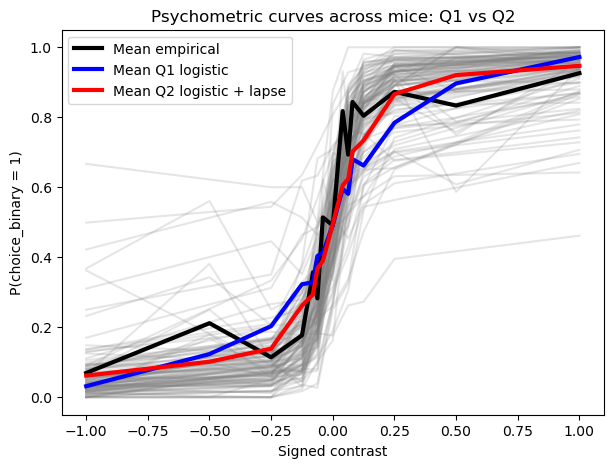

In [118]:
# Add Q2 Logistic + Lapse predictions
all_curves_df['p_test_lapse'] = [
    predict_proba_lapse_model(
        np.array([contrast]),
        mouse_logictic_lapse_models[subject]['params']['bias'],
        mouse_logictic_lapse_models[subject]['params']['contrast_weight'],
        mouse_logictic_lapse_models[subject]['params']['lapse_probability']
    )[0]
    for subject, contrast in zip(
        all_curves_df['subject'],
        all_curves_df['signed_contrast']
    )
]

mean_curve = (
    all_curves_df
    .groupby('signed_contrast', as_index=False)
    .agg(
        mean_empirical=('p_test_empirical', 'mean'),
        mean_q1=('p_test_predicted', 'mean'),
        mean_q2=('p_test_lapse', 'mean')
    )
)

plt.figure(figsize=(7, 5))

for subject, mouse_curve in all_curves_df.groupby('subject'):
    mouse_curve = mouse_curve.sort_values('signed_contrast')

    plt.plot(
        mouse_curve['signed_contrast'],
        mouse_curve['p_test_empirical'],
        color='gray',
        alpha=0.2
    )

plt.plot(
    mean_curve['signed_contrast'],
    mean_curve['mean_empirical'],
    color='black',
    linewidth=3,
    label='Mean empirical'
)

plt.plot(
    mean_curve['signed_contrast'],
    mean_curve['mean_q1'],
    color='blue',
    linewidth=3,
    label='Mean Q1 logistic'
)

plt.plot(
    mean_curve['signed_contrast'],
    mean_curve['mean_q2'],
    color='red',
    linewidth=3,
    label='Mean Q2 logistic + lapse'
)

plt.xlabel('Signed contrast')
plt.ylabel('P(choice_binary = 1)')
plt.title('Psychometric curves across mice: Q1 vs Q2')
plt.legend()
plt.show()

Next plot is for **one selected mouse**, identified by `subject` in Q1.

It compares:

* empirical test data for that mouse,
* the Q1 standard logistic model,
* the Q2 logistic + lapse model.

The curves show how both models predict that mouse’s choices across signed contrast levels.


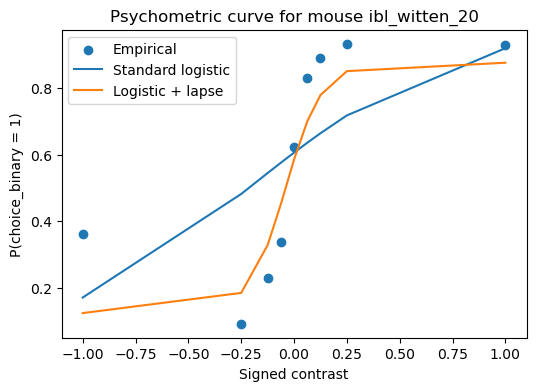

In [119]:
# Logistic + lapse model predictions
lapse_params = mouse_logictic_lapse_models[subject]['params']

p_test_lapse_curve = predict_proba_lapse_model(
    p_test_empirical.index.to_numpy(),
    lapse_params['bias'],
    lapse_params['contrast_weight'],
    lapse_params['lapse_probability']
)

# Plot
plt.figure(figsize=(6, 4))

plt.scatter(
    p_test_empirical.index,
    p_test_empirical.values,
    label='Empirical'
)

plt.plot(
    p_test_empirical.index,
    p_test_predicted_curve,
    label='Standard logistic'
)

plt.plot(
    p_test_empirical.index,
    p_test_lapse_curve,
    label='Logistic + lapse'
)

plt.xlabel('Signed contrast')
plt.ylabel('P(choice_binary = 1)')
plt.title(f'Psychometric curve for mouse {subject}')
plt.legend()
plt.show()

===================================================================================================================

#### Just Note

For classification, we usually use log loss / negative log-likelihood instead of squared error.

The reason is that the model predicts class probabilities, not regular numerical values.

- Log loss measures how well the predicted probability matches the true class.

- If the model gives a high probability to the correct class, the loss is small.

- If the model confidently gives a high probability to the wrong class, the loss becomes large.

### Интерпретация `log_likelihood`

|  `log_likelihood` | Интерпретация |
|---:|---|
| `0` to `-0.3` | Very good / очень хорошая модель |
| `-0.3` to `-0.5` | Good / хорошая модель |
| `-0.5` to `-0.65` | Okay / moderate / средняя модель |
| Around `-0.693` | Chance level / уровень случайного угадывания |
| Less than `-0.693` | Bad / хуже случайного угадывания |

In [120]:
# Save Q2 results for Q3

import pickle
import types
from pathlib import Path

Path("notebook_outputs").mkdir(exist_ok=True)

workspace = {}

for name, value in list(globals().items()):
    if name.startswith("_"):
        continue
    if name in ["In", "Out", "exit", "quit", "get_ipython"]:
        continue
    if isinstance(value, types.ModuleType):
        continue
    if callable(value):
        continue

    try:
        pickle.dumps(value)
        workspace[name] = value
    except Exception:
        pass

with open("notebook_outputs/q2_workspace.pkl", "wb") as f:
    pickle.dump(workspace, f)

print("saved q2")

saved q2
